# 02 : Structuration du dataset, splits et prétraitement

Le Notebook 01 a produit un inventaire complet des 27 558 images de cellules avec un audit qualité (corruption, doublons, dimensions). Ce notebook transforme cet inventaire en **dataset structuré et annoté, prêt pour l'entraînement d'un modèle** : un split train/validation/test groupé par patient et reproductible, et un pipeline de prétraitement (redimensionnement, normalisation, augmentation) implémenté avec les classes PyTorch `Dataset`/`DataLoader`.

## 1. Chargement et filtrage du manifeste

On charge le manifeste produit par le Notebook 01, puis on applique explicitement les indicateurs de qualité. Cette séparation garantit que les fichiers bruts ne sont jamais modifiés et que toute exclusion reste traçable.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader
from src.malaria_pipeline import MalariaCellDataset, denormalize
from torchvision import transforms

sns.set_theme(style="whitegrid")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

inventory = pd.read_csv(PROCESSED_DIR / "inventory.csv")
print(f"Manifeste complet : {len(inventory):,} lignes")
inventory.head(3)

Manifeste complet : 27,558 lignes


,path,label,filename,file_size_bytes,width,height,mode,md5,corrupted,duplicate
0,data\raw\cell_images\Parasitized\C100P61ThinF_...,Parasitized,C100P61ThinF_IMG_20150918_144104_cell_162.png,14025,142,148,RGB,6b60535df837d603b2f591d154940f1a,False,False
1,data\raw\cell_images\Parasitized\C100P61ThinF_...,Parasitized,C100P61ThinF_IMG_20150918_144104_cell_163.png,18152,148,208,RGB,142cdfcc8f5d2afcdd327e4886a4fbf8,False,False
2,data\raw\cell_images\Parasitized\C100P61ThinF_...,Parasitized,C100P61ThinF_IMG_20150918_144104_cell_164.png,12825,139,151,RGB,2db29c733097f1736cdba4055e1549d6,False,False


Le manifeste chargé contient 27 558 lignes et les champs nécessaires au contrôle (`path`, `label`, dimensions, hash et indicateurs qualité). La cellule suivante applique les exclusions documentées avant de construire les splits.


In [2]:
clean = inventory.loc[(~inventory["corrupted"]) & (~inventory["duplicate"])].reset_index(drop=True)

display(
    Markdown(
        f"**Exclues :** `{inventory['corrupted'].sum()}` lignes corrompues + `{inventory['duplicate'].sum()}` lignes en doublon.  \n"
        f"**Images utilisables :** `{len(clean):,}`"
    )
)
clean["label"].value_counts()

**Exclues :** `0` lignes corrompues + `0` lignes en doublon.  
**Images utilisables :** `27,558`

label
Parasitized    13779
Uninfected     13779
Name: count, dtype: int64

> **Observation.** Aucun fichier n'est exclu : les 27 558 images auditées restent disponibles, avec 13 779 observations par classe. La préparation peut donc porter sur l'intégralité du dataset.


## 2. Split train / validation / test par patient

Un split 70/15/15 est construit avec une seed fixe (42), **groupé par patient**. Les noms de fichiers encodent l'identifiant du patient (ex. `C116P77ThinF_IMG_...` : patient `C116P77` ; 200 patients au total), et un même patient contribue à des dizaines ou centaines de cellules, souvent issues du même champ de microscopie. Un split aléatoire par image placerait des cellules d'un même patient à la fois en entraînement et en test, ce qui gonfle les métriques. On utilise donc `sklearn.model_selection.GroupShuffleSplit` en deux étapes : 70% des patients pour l'entraînement, puis les 30% restants répartis à parts égales entre validation et test.

**Conséquence :** la stratification exacte par label n'est plus garantie (un patient a ses cellules dans un seul split) ; les proportions de classes restent proches de 50/50 et sont vérifiées ci-dessous.


In [3]:
clean["patient_id"] = clean["filename"].str.extract(r"^(.+?)_?[Tt]hin")[0]  # e.g. C100P61ThinF_..., C37BP2_thinF_..., C12NThinF_...
assert clean["patient_id"].notna().all(), "identifiant patient introuvable dans certains noms de fichier"
print(f"{clean['patient_id'].nunique()} patients distincts")

gss1 = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=SEED)
train_idx, temp_idx = next(gss1.split(clean, groups=clean["patient_id"]))
train_df, temp_df = clean.iloc[train_idx], clean.iloc[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=SEED)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["patient_id"]))
val_df, test_df = temp_df.iloc[val_idx], temp_df.iloc[test_idx]

# no patient may appear in two splits
assert not (set(train_df["patient_id"]) & set(val_df["patient_id"]))
assert not (set(train_df["patient_id"]) & set(test_df["patient_id"]))
assert not (set(val_df["patient_id"]) & set(test_df["patient_id"]))

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s}: {len(df):6,} images ({len(df) / len(clean):.1%}), {df['patient_id'].nunique()} patients")

split_summary = pd.concat(
    {
        "train": train_df["label"].value_counts(),
        "val": val_df["label"].value_counts(),
        "test": test_df["label"].value_counts(),
    },
    axis=1,
)
# Tableau explicite des effectifs et pourcentages par classe dans chaque split.
split_distribution = (split_summary[["train", "val", "test"]]
                      .rename_axis("label")
                      .reset_index()
                      .melt(id_vars="label", var_name="split", value_name="effectif"))
split_distribution["pourcentage"] = (
    split_distribution["effectif"]
    / split_distribution.groupby("split")["effectif"].transform("sum")
    * 100
).round(2)
split_distribution["effectif et pourcentage"] = split_distribution.apply(
    lambda row: f"{row['effectif']:,} ({row['pourcentage']:.2f} %)", axis=1
)
display(split_distribution.pivot(
    index="split", columns="label", values="effectif et pourcentage"
).loc[["train", "val", "test"]])

# Matrice exacte patients/classes : un patient peut contribuer aux deux classes.
split_manifest = pd.concat([
    df.assign(split=name) for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]
], ignore_index=True)
patient_class_matrix = (split_manifest.groupby(["split", "label"])
                        .agg(n_patients=("patient_id", "nunique"), n_images=("patient_id", "size"))
                        .reset_index())
display(patient_class_matrix)


200 patients distincts


train: 19,915 images (72.3%), 140 patients
val  :  3,623 images (13.1%), 30 patients
test :  4,020 images (14.6%), 30 patients


label,Parasitized,Uninfected
split,,
train,"10,234 (51.39 %)","9,681 (48.61 %)"
val,"1,573 (43.42 %)","2,050 (56.58 %)"
test,"1,972 (49.05 %)","2,048 (50.95 %)"


,split,label,n_patients,n_images
0,test,Parasitized,22,1972
1,test,Uninfected,30,2048
2,train,Parasitized,106,10234
3,train,Uninfected,140,9681
4,val,Parasitized,22,1573
5,val,Uninfected,30,2050


Le découpage obtenu comprend **19 915 images / 140 patients** pour l'entraînement, **3 623 / 30** pour la validation et **4 020 / 30** pour le test. Les assertions confirment qu'aucun patient ne chevauche deux ensembles.

La visualisation suivante contrôle la distribution des classes dans chaque split ; elle permet de rendre visible le compromis entre isolation des patients et équilibre exact des labels.


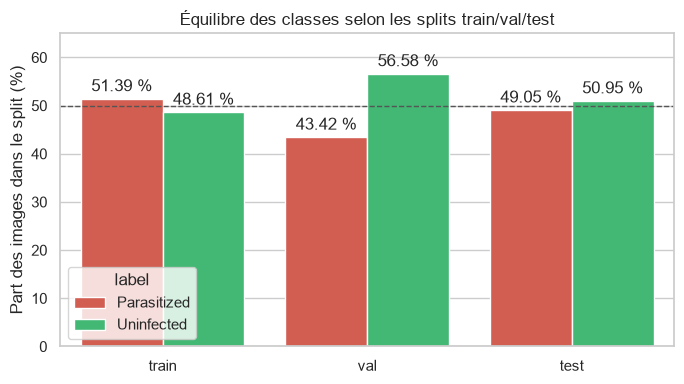

In [4]:
plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=split_distribution, x="split", y="pourcentage", hue="label",
    order=["train", "val", "test"],
    palette={"Parasitized": "#e74c3c", "Uninfected": "#2ecc71"},
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f %%", padding=3)
ax.axhline(50, color="#555555", linestyle="--", linewidth=1, label="Équilibre 50/50")
plt.title("Équilibre des classes selon les splits train/val/test")
plt.ylabel("Part des images dans le split (%)")
plt.ylim(0, 65)
plt.xlabel("")
plt.tight_layout()
plt.show()

> **Observation.** L'entraînement et le test restent proches de 50/50. La validation est plus déséquilibrée (43,42 % de cellules parasitées), conséquence acceptable du regroupement par patient et à prendre en compte avec des métriques par classe.


Le split par patient garde les classes proches de l'équilibre 50/50 (train 51/49, validation 43/57, test 49/51) : l'écart de la validation vient du fait qu'un patient, et toutes ses cellules, tombe dans un seul sous-ensemble. L'accuracy reste donc lisible, mais les métriques cliniquement pertinentes (sensibilité, spécificité, VPP, VPN) sont suivies séparément dans le Notebook 04, la prévalence réelle étant loin d'être 50/50.

## 3. Pipeline de prétraitement

**Taille cible du redimensionnement : 64x64 px.** Les images sources sont des recadrages de cellule unique en basse résolution (taille médiane autour de 130x130 px d'après le Notebook 01), sans détail sous-cellulaire fin en dehors du motif de coloration, et l'entraînement tourne uniquement sur CPU (pas de CUDA sur cette machine). 64x64 permet de garder chaque passe avant/arrière assez rapide pour entraîner plusieurs modèles en quelques minutes, tout en conservant assez de résolution pour voir clairement la coloration du parasite, vérifié visuellement ci-dessous.

**Normalisation :** les moyennes/écarts-types ImageNet (`[0.485, 0.456, 0.406]` / `[0.229, 0.224, 0.225]`) sont utilisés à la fois pour le CNN from scratch et pour le modèle de transfer learning du Notebook 03, plutôt que des statistiques propres au dataset. Cela garde les deux pipelines directement comparables et est de toute façon requis pour la branche de transfer learning, puisque les filtres pré-entraînés de `resnet18` attendent une entrée normalisée façon ImageNet.

**Augmentation (split d'entraînement uniquement) :** flip horizontal aléatoire, flip vertical aléatoire, et une petite rotation aléatoire (±15°). L'orientation des cellules au microscope est arbitraire, donc ces flips/rotations préservent le label et rendent simplement le jeu d'entraînement plus représentatif des orientations de lames non vues. Aucune augmentation n'est appliquée sur validation/test, puisque ces splits doivent refléter les données telles qu'elles arrivent réellement.

In [5]:
IMG_SIZE = 64
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print(train_transform)

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


> **Décision.** Le pipeline retient une entrée 64×64, la normalisation ImageNet et des augmentations géométriques uniquement à l'entraînement. Validation et test restent déterministes pour fournir une mesure comparable entre modèles.


## 4. `Dataset` et `DataLoader` PyTorch

In [6]:
LABEL_TO_IDX = {"Uninfected": 0, "Parasitized": 1}
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}


train_dataset = MalariaCellDataset(train_df.assign(label=train_df["label"]), PROJECT_ROOT, transform=train_transform)
val_dataset = MalariaCellDataset(val_df, PROJECT_ROOT, transform=eval_transform)
test_dataset = MalariaCellDataset(test_df, PROJECT_ROOT, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

batch_x, batch_y = next(iter(train_loader))
print(f"train_dataset: {len(train_dataset):,} | val_dataset: {len(val_dataset):,} | test_dataset: {len(test_dataset):,}")
print(f"Forme du batch : {batch_x.shape}, dtype {batch_x.dtype} ; forme des labels {batch_y.shape}")

train_dataset: 19,915 | val_dataset: 3,623 | test_dataset: 4,020
Forme du batch : torch.Size([32, 3, 64, 64]), dtype torch.float32 ; forme des labels torch.Size([32])


> **Contrôle technique.** Les trois datasets contiennent respectivement 19 915, 3 623 et 4 020 images. Un batch a la forme attendue `[32, 3, 64, 64]`, ce qui valide le chaînage manifeste → chargement RGB → transformation → tenseur.


### Vérification visuelle : un batch d'images d'entraînement augmentées

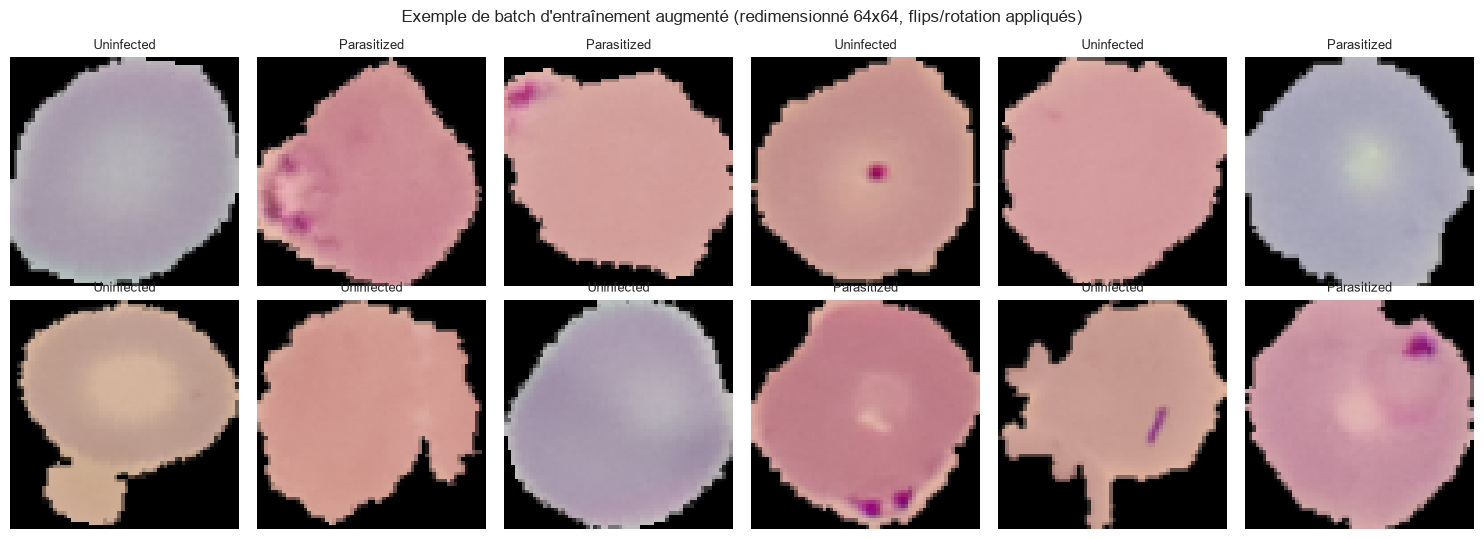

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for i in range(12):
    img = denormalize(batch_x[i], IMAGENET_MEAN, IMAGENET_STD).permute(1, 2, 0).numpy()
    ax = axes[i // 6, i % 6]
    ax.imshow(img)
    ax.set_title(IDX_TO_LABEL[batch_y[i].item()], fontsize=9)
    ax.axis("off")
fig.suptitle("Exemple de batch d'entraînement augmenté (redimensionné 64x64, flips/rotation appliqués)", fontsize=12)
plt.tight_layout()
plt.show()

Même à une résolution de 64x64, le motif de coloration qui distingue les cellules parasitées des cellules saines reste visible, ce qui confirme le compromis résolution/vitesse fait plus haut. Les recadrages augmentés (flip/rotation) ressemblent toujours à des champs de microscopie plausibles, ce qui confirme que les transformations préservent bien le label.

## 5. Export des manifestes annotés

In [8]:
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    out_path = PROCESSED_DIR / f"{name}.csv"
    df[["path", "label", "patient_id"]].to_csv(out_path, index=False)
    print(f"{out_path.name} sauvegardé : {len(df):,} lignes")

# Manifeste reproductible complet : seed, patient, classe, image et split.
split_manifest[["path", "label", "patient_id", "split"]].assign(seed=SEED).to_csv(
    PROCESSED_DIR / "split_manifest.csv", index=False
)
patient_class_matrix.to_csv(PROCESSED_DIR / "patient_class_matrix.csv", index=False)
print(f"Seed du split : {SEED} ; manifestes patient publiés.")

train.csv sauvegardé : 19,915 lignes
val.csv sauvegardé : 3,623 lignes
test.csv sauvegardé : 4,020 lignes
Seed du split : 42 ; manifestes patient publiés.


> **Résultat.** Les trois manifestes annotés sont enregistrés dans `data/processed/`. La graine 42 et les identifiants patients sont publiés avec les chemins et labels, de sorte que les expériences du Notebook 03 puissent être reproduites sans recalculer le split.


## Résumé

* Split 70/15/15 groupé par patient (`GroupShuffleSplit`, 200 patients : 140 / 30 / 30), seed 42, sauvegardé dans `data/processed/{train,val,test}.csv` ; tailles indiquées dans la Section 2 ci-dessus.
* Prétraitement : redimensionnement en 64x64, normalisation ImageNet, augmentation sur l'entraînement uniquement (flip horizontal/vertical, plus ou moins 15 degrés de rotation).
* Classes `MalariaCellDataset` / `DataLoader` définies et vérifiées sur un batch réel.
* Aucun patient n'apparaît dans deux splits (vérifié par assertion) ; en contrepartie, la stratification exacte par label n'est plus garantie.

## Décisions pour le Notebook 03

1. Entraîner tous les modèles sur le même split complet et avec les mêmes transformations d'évaluation.
2. Comparer un CNN appris de zéro à une ResNet18 pré-entraînée, sans supposer que le transfert depuis ImageNet sera supérieur en microscopie.
3. Sélectionner le modèle sur la validation uniquement ; préserver le test pour une évaluation finale unique dans le Notebook 04.
4. Suivre au minimum la loss, l'accuracy et le F1 de la classe `Parasitized`.
